In [60]:
import warnings; warnings.filterwarnings("ignore")  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
import matplotlib.pyplot as plt  
import numpy as np  

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False  
np.random.seed(62)

In [62]:

df = pd.read_csv("data/hr_clean.csv")
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level,Hire_Year
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8.0,Active,On-site,92992.0,2023,Germany,Munich,32,Mid,2023
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11.0,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior,2008
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15.0,Active,On-site,111121.0,2016,Spain,Seville,43,Senior,2016
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1.0,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior,2024
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2.0,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior,2024


In [3]:
print("*"* 55)

print("*"* 55)

*******************************************************
*******************************************************


In [64]:
print("review dataset")
print("dataset is :" , df.shape)
print("*"* 40)
print(df.head())
print("*"* 40)
print(df.dtypes)
print("*"* 40)
print(df.describe())

review dataset
dataset is : (2000000, 16)
****************************************
  Employee_ID                             Full_Name  Department  \
0  EMP0000001                     Heinz-Georg Eimer       Sales   
1  EMP0000002  Maartje van den Nuwenhuysen-Geertsen          HR   
2  EMP0000003                  Sara Sureda Figueroa          HR   
3  EMP0000004                          Luce Sanchez  Operations   
4  EMP0000005                      William Jennings       Sales   

              Job_Title   Hire_Date Performance_Rating  Experience_Years  \
0  Business Development  2023-01-31       Satisfactory               8.0   
1            HR Manager  2008-11-07               Good              11.0   
2     Talent Specialist  2016-03-19  Needs Improvement              15.0   
3   Operations Director  2024-04-03               Good               1.0   
4         Regional Lead  2024-11-17               Good               2.0   

   Status Work_Mode    Salary  Year         Country      

In [65]:
print("feature creation")
print("+"*90)
df['Salary_Band'] = pd.cut(
    df['Salary'],
    bins = [0, 40000, 60000, 90000, 130000, 9999990],
    labels = ['very low' , 'low' , 'medium' , 'hight' , 'very hight']  
)

df['Age_Group'] = pd.cut(
    df['Age'],
    bins = [0 , 30 , 40 , 50 , 99],
    labels = ['young' , 'midage' , 'senior' , 'god']  
)

df['Tenure_Years'] = df['Year'] - df['Hire_Year']
df['Tenure_Years'] = df['Tenure_Years'].clip(0)

df['Salary_per_Exp'] = (df['Salary'] / (df['Experience_Years'] + 1)).round(1)

print(df[['Salary' , 'Salary_Band' , 'Age' , 'Age_Group' , 'Hire_Year','Year','Tenure_Years','Salary_per_Exp']].head(30))

feature creation
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
      Salary Salary_Band  Age Age_Group  Hire_Year  Year  Tenure_Years  \
0    92992.0       hight   32    midage       2023  2023             0   
1   112318.0       hight   43    senior       2008  2008             0   
2   111121.0       hight   43    senior       2016  2016             0   
3    49012.0         low   23     young       2024  2024             0   
4    57553.0         low   31    midage       2024  2024             0   
5    49644.0         low   27     young       2024  2024             0   
6    44048.0         low   26     young       2025  2025             0   
7   158805.0  very hight   41    senior       2018  2018             0   
8   178720.0  very hight   49    senior       2008  2008             0   
9    67335.0      medium   26     young       2021  2021             0   
10   55615.0         low   24     young       2024  2024             0   
11  

In [66]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,Year,Country,City,Age,Job_Level,Hire_Year,Salary_Band,Age_Group,Tenure_Years,Salary_per_Exp
0,EMP0000001,Heinz-Georg Eimer,Sales,Business Development,2023-01-31,Satisfactory,8.0,Active,On-site,92992.0,2023,Germany,Munich,32,Mid,2023,hight,midage,0,10332.4
1,EMP0000002,Maartje van den Nuwenhuysen-Geertsen,HR,HR Manager,2008-11-07,Good,11.0,Active,On-site,112318.0,2008,Netherlands,Eindhoven,43,Senior,2008,hight,senior,0,9359.8
2,EMP0000003,Sara Sureda Figueroa,HR,Talent Specialist,2016-03-19,Needs Improvement,15.0,Active,On-site,111121.0,2016,Spain,Seville,43,Senior,2016,hight,senior,0,6945.1
3,EMP0000004,Luce Sanchez,Operations,Operations Director,2024-04-03,Good,1.0,Active,Hybrid,49012.0,2024,France,Marseille,23,Junior,2024,low,young,0,24506.0
4,EMP0000005,William Jennings,Sales,Regional Lead,2024-11-17,Good,2.0,Active,On-site,57553.0,2024,United Kingdom,Edinburgh,31,Junior,2024,low,midage,0,19184.3


In [67]:
# df = df.sort_values('Age')
df = df.sort_values('Age' , ascending = True).reset_index(drop = True)
print(df.head(10))

  Employee_ID                           Full_Name  Department  \
0  EMP0853013             Herr Mohamed Zahn B.Sc.  Operations   
1  EMP1222317                  Cecilia Neuschäfer     Finance   
2  EMP1436500      Frau Annekatrin Seifert B.Eng.  Operations   
3  EMP1436495                   Mr Dominic Clarke          IT   
4  EMP1436488  Univ.Prof. Hans-Karl Weinhold MBA.     Finance   
5  EMP0097100              Noémi Dos Santos-Peron  Operations   
6  EMP0938829                     Brigitte Coulon  Operations   
7  EMP1868668                        Carmen Ojeda          IT   
8  EMP0097079                   pan Patryk Syroka  Operations   
9  EMP0789201               William Dörr-Fliegner     Finance   

             Job_Title   Hire_Date Performance_Rating  Experience_Years  \
0  Operations Director  2025-09-10          Excellent               0.0   
1           Accountant  2025-11-02       Satisfactory               0.0   
2   Operations Analyst  2025-06-21               Good      

In [68]:
print('str methods')
print("*"* 40)

df['Job_Title_Upper'] = df['Job_Title'].str.upper()
df['First_Name'] = df['Full_Name'].str.split('-').str[0]
df['Is_Manager'] = df['Job_Title'].str.contains('Manager' , case = False)
print(df[['Full_Name','First_Name','Job_Title','Job_Title_Upper','Is_Manager']].head(8))

str methods
****************************************
                            Full_Name                      First_Name  \
0             Herr Mohamed Zahn B.Sc.         Herr Mohamed Zahn B.Sc.   
1                  Cecilia Neuschäfer              Cecilia Neuschäfer   
2      Frau Annekatrin Seifert B.Eng.  Frau Annekatrin Seifert B.Eng.   
3                   Mr Dominic Clarke               Mr Dominic Clarke   
4  Univ.Prof. Hans-Karl Weinhold MBA.                 Univ.Prof. Hans   
5              Noémi Dos Santos-Peron                Noémi Dos Santos   
6                     Brigitte Coulon                 Brigitte Coulon   
7                        Carmen Ojeda                    Carmen Ojeda   

             Job_Title      Job_Title_Upper  Is_Manager  
0  Operations Director  OPERATIONS DIRECTOR       False  
1           Accountant           ACCOUNTANT       False  
2   Operations Analyst   OPERATIONS ANALYST       False  
3   Software Developer   SOFTWARE DEVELOPER       False  

In [69]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,...,Age,Job_Level,Hire_Year,Salary_Band,Age_Group,Tenure_Years,Salary_per_Exp,Job_Title_Upper,First_Name,Is_Manager
0,EMP0853013,Herr Mohamed Zahn B.Sc.,Operations,Operations Director,2025-09-10,Excellent,0.0,Resigned,On-site,49970.0,...,21,Junior,2025,low,young,0,49970.0,OPERATIONS DIRECTOR,Herr Mohamed Zahn B.Sc.,False
1,EMP1222317,Cecilia Neuschäfer,Finance,Accountant,2025-11-02,Satisfactory,0.0,Active,Hybrid,44270.0,...,21,Junior,2025,low,young,0,44270.0,ACCOUNTANT,Cecilia Neuschäfer,False
2,EMP1436500,Frau Annekatrin Seifert B.Eng.,Operations,Operations Analyst,2025-06-21,Good,0.0,Active,On-site,48870.0,...,21,Junior,2025,low,young,0,48870.0,OPERATIONS ANALYST,Frau Annekatrin Seifert B.Eng.,False
3,EMP1436495,Mr Dominic Clarke,IT,Software Developer,2024-05-29,Excellent,0.0,Active,On-site,62990.0,...,21,Junior,2024,medium,young,0,62990.0,SOFTWARE DEVELOPER,Mr Dominic Clarke,False
4,EMP1436488,Univ.Prof. Hans-Karl Weinhold MBA.,Finance,Finance Manager,2016-04-09,Good,0.0,Active,Remote,46674.0,...,21,Junior,2016,low,young,0,46674.0,FINANCE MANAGER,Univ.Prof. Hans,True


In [70]:
print('groupby \n')
print("*"* 40)
dept_states = df.groupby('Department').agg(
    count = ('Employee_ID' , 'count'),
    mean_salary = ('Salary'  , 'mean'),
    mean_experience = ('Experience_Years' , 'mean'),  
    most_common_rating = ('Performance_Rating' , lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A')    
).round(1)

print(dept_states)

groupby 

****************************************
             count  mean_salary  mean_experience most_common_rating
Department                                                         
Finance     299955      94459.9              6.3               Good
HR          199492      74582.2              6.3               Good
IT          499325      96542.8              6.3               Good
Operations  400595      84900.1              6.3               Good
Sales       600633      91457.9              6.3               Good


In [71]:
print('transform')
print('*'*40)

df['Dept_avg_salary'] = df.groupby('Department')['Salary'].transform('mean').round(0)
df['Salary_vs_dept'] = (df['Salary'] - df['Dept_avg_salary']).round(0)  # Fixed: changed 'rounf' to 'round'

# Fixed: corrected column name cases to match the created columns
print(df[['Full_Name' , 'Department','Salary','Dept_avg_salary','Salary_vs_dept']].head(20))

transform
****************************************
                             Full_Name  Department   Salary  Dept_avg_salary  \
0              Herr Mohamed Zahn B.Sc.  Operations  49970.0          84900.0   
1                   Cecilia Neuschäfer     Finance  44270.0          94460.0   
2       Frau Annekatrin Seifert B.Eng.  Operations  48870.0          84900.0   
3                    Mr Dominic Clarke          IT  62990.0          96543.0   
4   Univ.Prof. Hans-Karl Weinhold MBA.     Finance  46674.0          94460.0   
5               Noémi Dos Santos-Peron  Operations  47697.0          84900.0   
6                      Brigitte Coulon  Operations  50157.0          84900.0   
7                         Carmen Ojeda          IT  45122.0          96543.0   
8                    pan Patryk Syroka  Operations  53162.0          84900.0   
9                William Dörr-Fliegner     Finance  63517.0          94460.0   
10                       Félix Calleja          HR  47590.0          

In [72]:
print('value_counts , crosstab \n')
print('*'*60)

# print('work_mode:')
print(df['Work_Mode'].value_counts())
print('_'*80)

print('crosstab * work_modoe')
print(pd.crosstab(df['Department'] , df['Work_Mode'] , margins = True))

value_counts , crosstab 

************************************************************
Work_Mode
On-site    1099347
Remote      550096
Hybrid      350557
Name: count, dtype: int64
________________________________________________________________________________
crosstab * work_modoe
Work_Mode   Hybrid  On-site  Remote      All
Department                                  
Finance      45345   179613   74997   299955
HR           29898   119570   50024   199492
IT          125052   200004  174269   499325
Operations   60115   239883  100597   400595
Sales        90147   360277  150209   600633
All         350557  1099347  550096  2000000


In [73]:
print('pivot_table \n')

pivot = df.pivot_table(
    values = 'Salary' ,
    index = 'Department',
    columns = 'Work_Mode',
    aggfunc = 'mean'
).round(0)

print(pivot)
    

pivot_table 

Work_Mode    Hybrid  On-site   Remote
Department                           
Finance     94992.0  94546.0  93932.0
HR          74753.0  74537.0  74588.0
IT          96645.0  96470.0  96553.0
Operations  84841.0  84892.0  84956.0
Sales       91181.0  91501.0  91521.0


In [74]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Performance_Rating,Experience_Years,Status,Work_Mode,Salary,...,Hire_Year,Salary_Band,Age_Group,Tenure_Years,Salary_per_Exp,Job_Title_Upper,First_Name,Is_Manager,Dept_avg_salary,Salary_vs_dept
0,EMP0853013,Herr Mohamed Zahn B.Sc.,Operations,Operations Director,2025-09-10,Excellent,0.0,Resigned,On-site,49970.0,...,2025,low,young,0,49970.0,OPERATIONS DIRECTOR,Herr Mohamed Zahn B.Sc.,False,84900.0,-34930.0
1,EMP1222317,Cecilia Neuschäfer,Finance,Accountant,2025-11-02,Satisfactory,0.0,Active,Hybrid,44270.0,...,2025,low,young,0,44270.0,ACCOUNTANT,Cecilia Neuschäfer,False,94460.0,-50190.0
2,EMP1436500,Frau Annekatrin Seifert B.Eng.,Operations,Operations Analyst,2025-06-21,Good,0.0,Active,On-site,48870.0,...,2025,low,young,0,48870.0,OPERATIONS ANALYST,Frau Annekatrin Seifert B.Eng.,False,84900.0,-36030.0
3,EMP1436495,Mr Dominic Clarke,IT,Software Developer,2024-05-29,Excellent,0.0,Active,On-site,62990.0,...,2024,medium,young,0,62990.0,SOFTWARE DEVELOPER,Mr Dominic Clarke,False,96543.0,-33553.0
4,EMP1436488,Univ.Prof. Hans-Karl Weinhold MBA.,Finance,Finance Manager,2016-04-09,Good,0.0,Active,Remote,46674.0,...,2016,low,young,0,46674.0,FINANCE MANAGER,Univ.Prof. Hans,True,94460.0,-47786.0


In [75]:
print('finish the first section')

finish the first section


In [76]:
print('_'*70)
print('matplotlib')
print('_'*70)

______________________________________________________________________
matplotlib
______________________________________________________________________


line chart salary


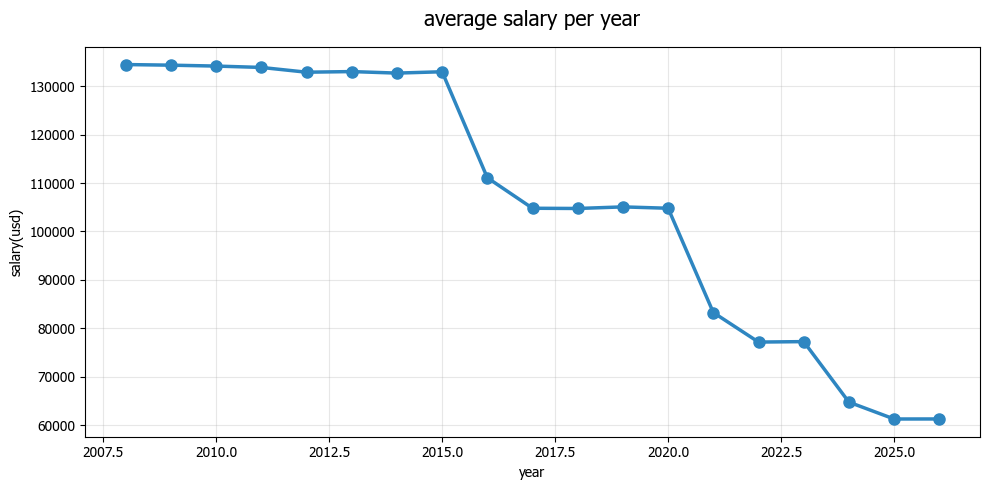

saved chart


In [77]:
import os 
print('line chart salary')


salary_trend = df.groupby('Year')['Salary'].mean().round(0)
plt.figure(figsize = (10,5))

plt.plot(salary_trend.index, salary_trend.values,
         marker='o', linewidth=2.5, color='#2E86C1', markersize=8)

plt.title('average salary per year', fontsize=15, pad=15)
plt.xlabel('year')
plt.ylabel('salary(usd)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True) 


plt.show()
print('saved chart')

bar chart department
____________________________________________________________


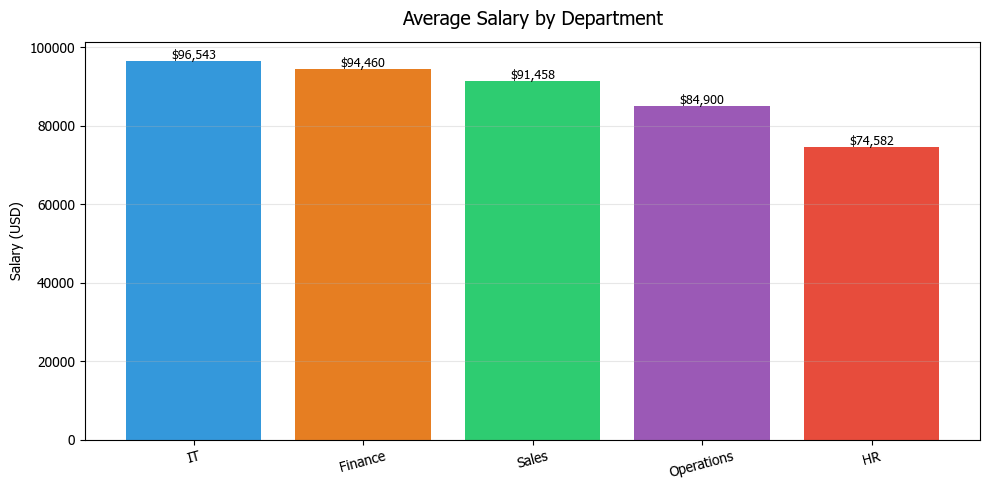

ommmm


In [78]:
print('bar chart department')
print('_'*60)

dept_salary = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
bars = plt.bar(dept_salary.index, dept_salary.values,
               color=['#3498DB','#E67E22','#2ECC71','#9B59B6','#E74C3C','#1ABC9C'])
for bar, val in zip(bars, dept_salary.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', fontsize=9)
plt.title('Average Salary by Department', fontsize=14, pad=12)
plt.ylabel('Salary (USD)')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print("ommmm")

scatter - exprience vs salary
____________________________________________________________


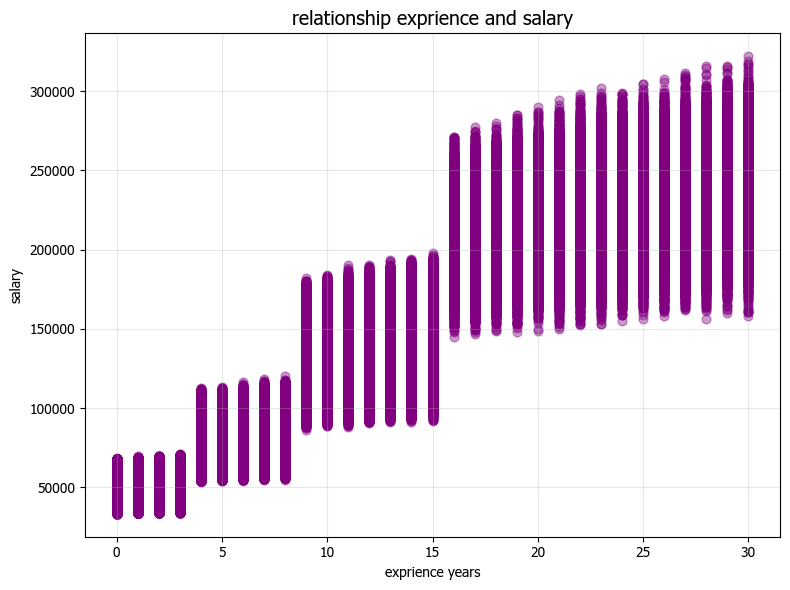

successful


In [79]:
print('scatter - exprience vs salary')
print('_'*60)


 
plt.figure(figsize=(8,6))
plt.scatter(df['Experience_Years'], df['Salary'],
            alpha=0.4, c='purple', s=40)
plt.title('relationship exprience and salary', fontsize=14)
plt.xlabel('exprience years')
plt.ylabel('salary')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('successful')



 Histogram — Salary Distribution


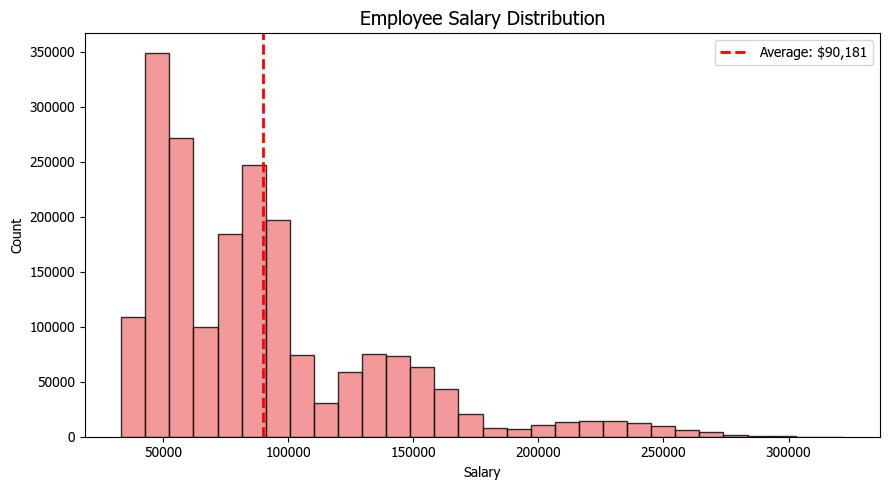

ok


In [80]:
print("\n Histogram — Salary Distribution")
 
plt.figure(figsize=(9,5))
plt.hist(df['Salary'], bins=30, color='lightcoral', edgecolor='black', alpha=0.8)
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', linewidth=2, label=f"Average: ${df['Salary'].mean():,.0f}")
plt.title('Employee Salary Distribution', fontsize=14)
plt.xlabel('Salary')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
print('ok')



 Boxplot — Salary Distribution Comparison


<Figure size 1000x600 with 0 Axes>

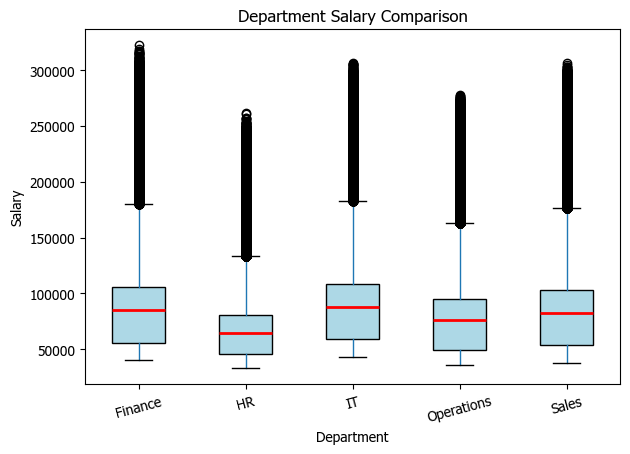

ok


In [81]:
 print("\n Boxplot — Salary Distribution Comparison")
 
plt.figure(figsize=(10,6))
df.boxplot(column='Salary', by='Department', grid=False,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))
plt.title('Department Salary Comparison')
plt.suptitle('')
plt.ylabel('Salary')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("ok")
 


 Pie Chart — Work Mode Distribution


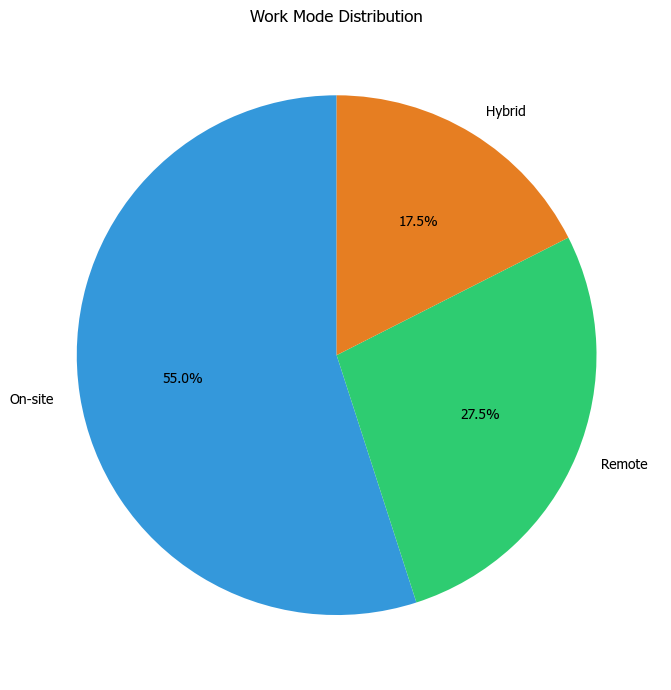

ok


In [82]:
# ── 2.6  Pie — Work Mode Distribution ─────────────────────────────────
print("\n Pie Chart — Work Mode Distribution")
 
wm = df['Work_Mode'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(wm, labels=wm.index, autopct='%1.1f%%', startangle=90,
        colors=['#3498DB','#2ECC71','#E67E22'])
plt.title('Work Mode Distribution')
plt.tight_layout()
plt.show()
print("ok")


 Dashboard — 4 Charts Combined


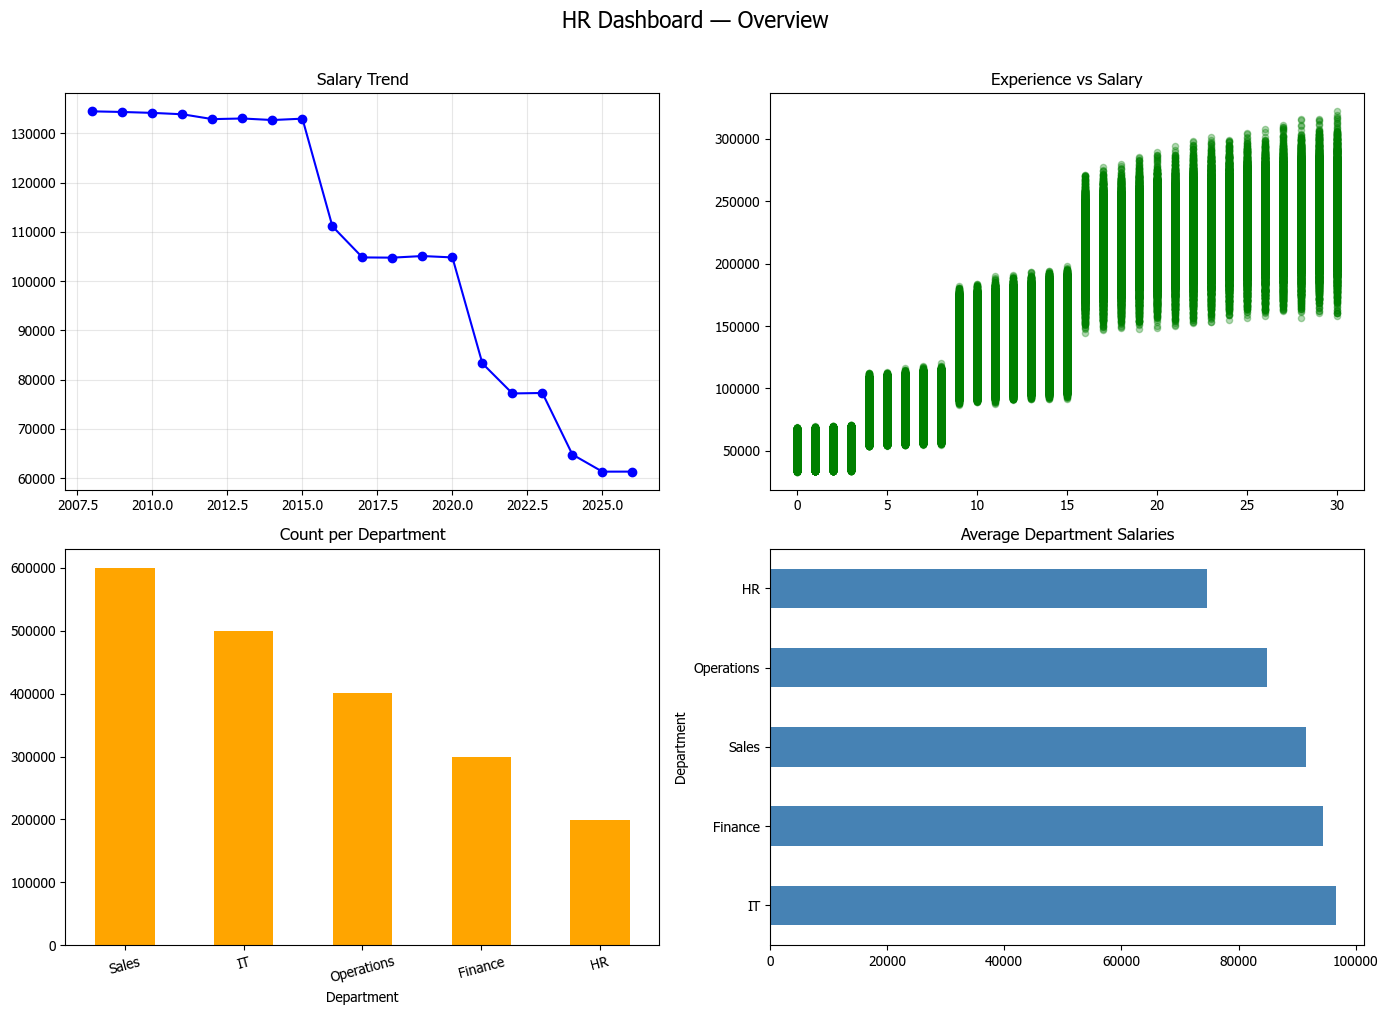

ok


In [83]:
print("\n Dashboard — 4 Charts Combined")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
axes[0,0].plot(salary_trend.index, salary_trend.values, marker='o', color='blue')
axes[0,0].set_title('Salary Trend')
axes[0,0].grid(True, alpha=0.3)
 
axes[0,1].scatter(df['Experience_Years'], df['Salary'], alpha=0.3, color='green', s=20)
axes[0,1].set_title('Experience vs Salary')
 
df['Department'].value_counts().plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Count per Department')
axes[1,0].tick_params(axis='x', rotation=15)
 
dept_salary.plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Average Department Salaries')
 
plt.suptitle('HR Dashboard — Overview', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()
print("ok")

In [85]:
print("=" * 55)
print("Seaborn")
print("=" * 55)

Seaborn



 histplot + KDE — Salary Distribution


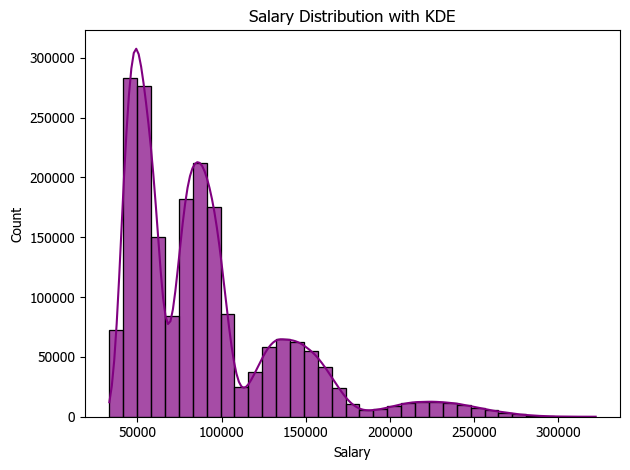

yeeeee


In [86]:
print("\n histplot + KDE — Salary Distribution")
 
sns.histplot(data=df, x='Salary', bins=35, kde=True,
             color='purple', alpha=0.7)
plt.title('Salary Distribution with KDE')
plt.tight_layout()
plt.show()
print("yeeeee")



 regplot — Regression Line


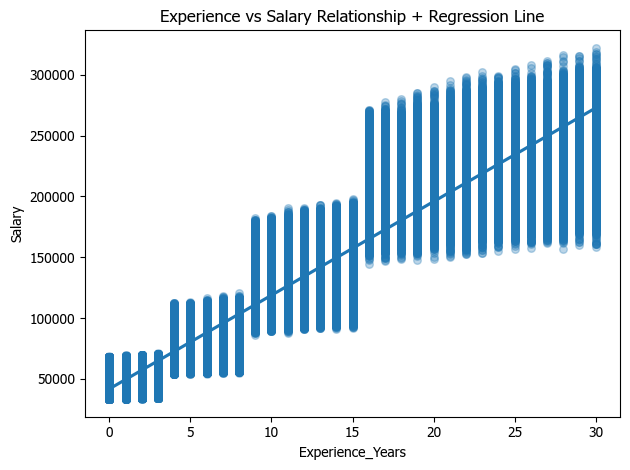

yeeee


In [87]:
 print("\n regplot — Regression Line")
 
sns.regplot(x='Experience_Years', y='Salary', data=df,
            scatter_kws={'alpha':0.3, 's':30})
plt.title('Experience vs Salary Relationship + Regression Line')
plt.tight_layout()
plt.show()
print("yeeee")



 boxplot seaborn — Salary by Work Mode


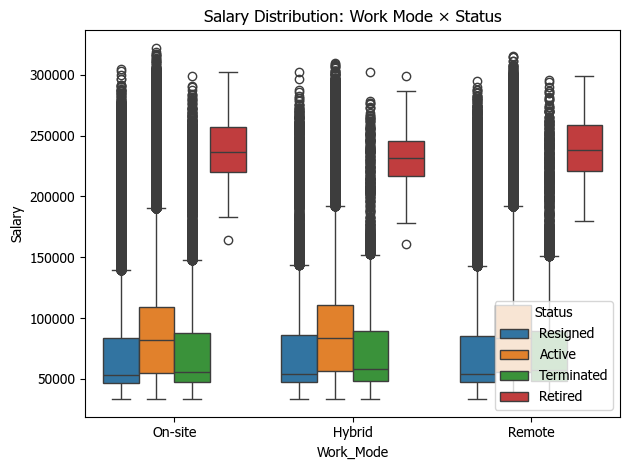

ok


In [88]:
print("\n boxplot seaborn — Salary by Work Mode")
 
sns.boxplot(x='Work_Mode', y='Salary', hue='Status', data=df)
plt.title('Salary Distribution: Work Mode × Status')
plt.tight_layout()
plt.show()
print("ok")


 heatmap — Correlation Matrix


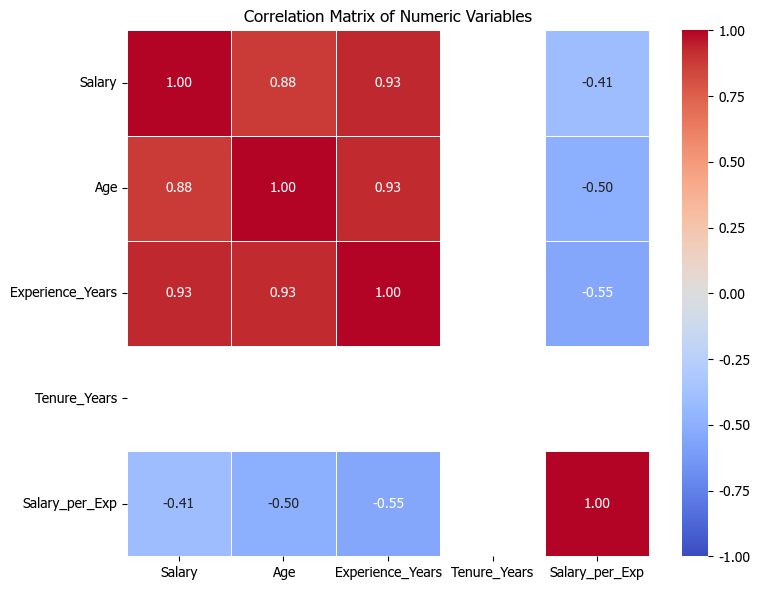

yeeee


In [89]:
print("\n heatmap — Correlation Matrix")
 
numeric_cols = ['Salary','Age','Experience_Years','Performance_Rating',
                'Tenure_Years','Salary_per_Exp']

actual_numeric_cols = df[numeric_cols].select_dtypes(include=['number']).columns.tolist()

corr = df[actual_numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()
print("yeeee")


 catplot — Performance Rating Comparison


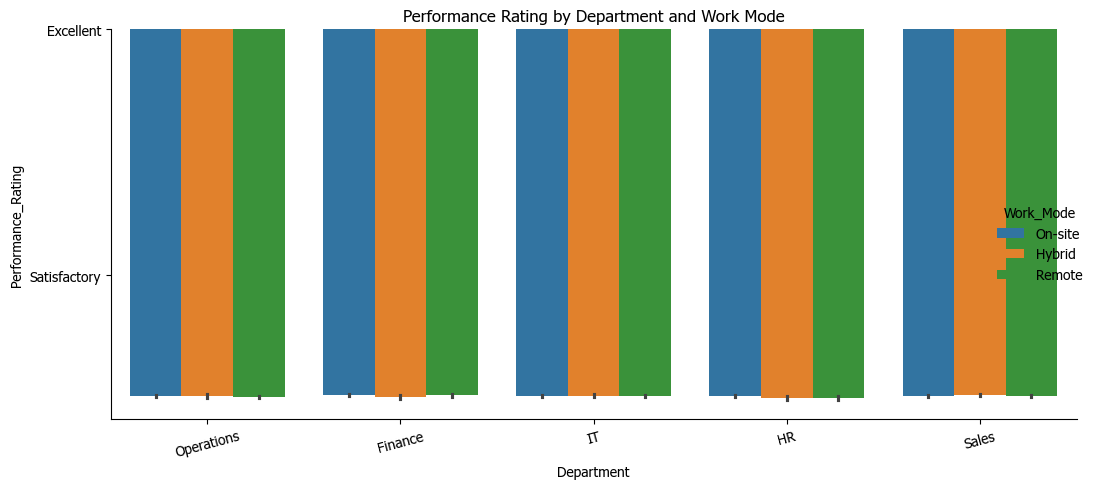

 yeeee


In [90]:
print("\n catplot — Performance Rating Comparison")
 
sns.catplot(x='Department', y='Performance_Rating',
            hue='Work_Mode', kind='bar',
            data=df, height=5, aspect=2)
plt.title('Performance Rating by Department and Work Mode')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print(" yeeee")


 pairplot — All Relationships Together


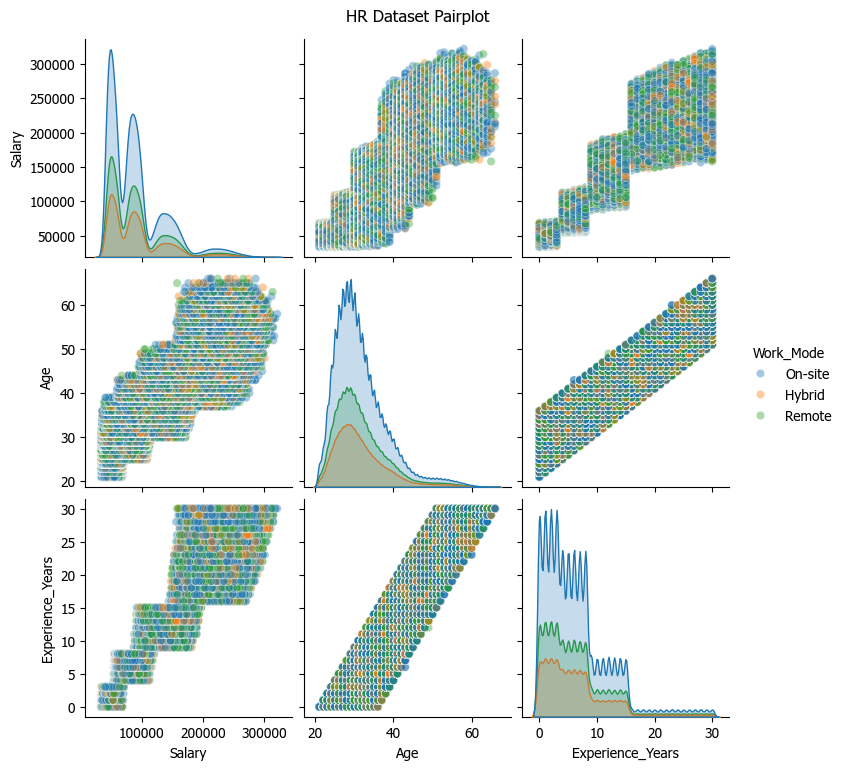

ok


In [91]:
print("\n pairplot — All Relationships Together")
 
pair_df = df[['Salary','Age','Experience_Years','Performance_Rating','Work_Mode']].copy()
sns.pairplot(pair_df, hue='Work_Mode', diag_kind='kde',
             plot_kws={'alpha':0.4})
plt.suptitle('HR Dataset Pairplot', y=1.02)
plt.show()
print("ok")

## part two

In [92]:
print("*"*50)
print("feature engineering")
print("*"*50)

**************************************************
feature engineering
**************************************************


In [93]:
print("ratio features")


df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Experience_Years'] = pd.to_numeric(df['Experience_Years'], errors='coerce')
df['Tenure_Years'] = pd.to_numeric(df['Tenure_Years'], errors='coerce')
df['Performance_Rating'] = pd.to_numeric(df['Performance_Rating'], errors='coerce')


df['Salary_Age_Ratio'] = (df['Salary'] / df['Age']).round(1)
df['Exp_Tenure_Ratio'] = (df['Experience_Years'] / (df['Tenure_Years'] + 1)).round(2)
df['Salary_Ratio_Product'] = (df['Salary'] * df['Performance_Rating']).round(0)

print(df[['Salary','Age','Salary_Age_Ratio',
          'Experience_Years','Tenure_Years','Exp_Tenure_Ratio']].head(3))

ratio features
    Salary  Age  Salary_Age_Ratio  Experience_Years  Tenure_Years  \
0  49970.0   21            2379.5               0.0             0   
1  44270.0   21            2108.1               0.0             0   
2  48870.0   21            2327.1               0.0             0   

   Exp_Tenure_Ratio  
0               0.0  
1               0.0  
2               0.0  


math transform


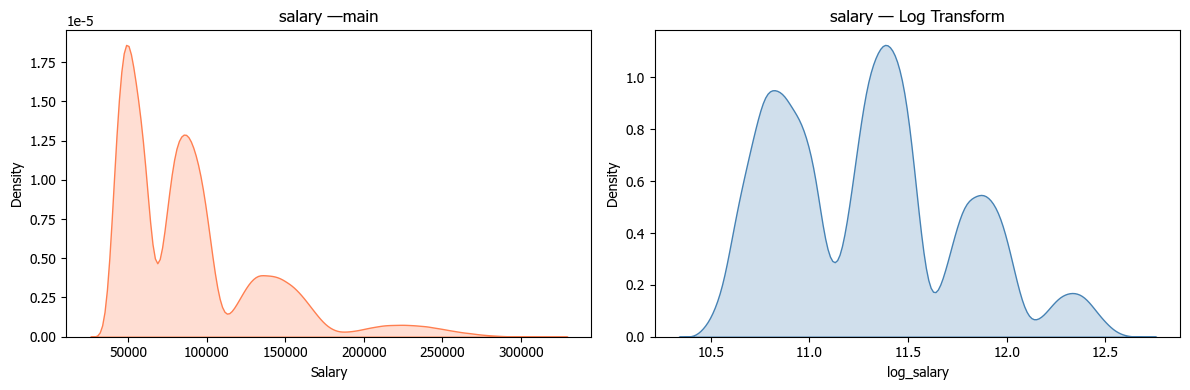

yeeep


In [94]:
print('math transform')


df['log_salary'] = np.log1p(df['Salary'])
df['sqr_exp'] = np.sqrt(df['Experience_Years'])  

fig , axes = plt.subplots(1,2,figsize = (12,4))
sns.kdeplot(df['Salary'], fill=True, ax=axes[0], color='coral')
axes[0].set_title('salary —main')
 
sns.kdeplot(df['log_salary'], fill=True, ax=axes[1], color='steelblue')
axes[1].set_title('salary — Log Transform')
plt.tight_layout()
plt.show()
print("yeeep")

In [95]:
print("count features")

df['Dept_Count']   = df.groupby('Department')['Employee_ID'].transform('count')
df['City_Count']   = df.groupby('City')['Employee_ID'].transform('count')
df['Country_Freq'] = df.groupby('Country')['Employee_ID'].transform('count') / len(df)

df = df.sort_index()
print(df[['Department','Dept_Count','City','City_Count','Country','Country_Freq']].head(50))

count features
    Department  Dept_Count        City  City_Count         Country  \
0   Operations      400595     Hamburg       88429         Germany   
1      Finance      299955      Munich       87968         Germany   
2   Operations      400595   Frankfurt       88362         Germany   
3           IT      499325      London       99768  United Kingdom   
4      Finance      299955      Berlin       87914         Germany   
5   Operations      400595    Toulouse       79797          France   
6   Operations      400595        Nice       80327          France   
7           IT      499325   Barcelona       52076           Spain   
8   Operations      400595      Poznan       12116          Poland   
9      Finance      299955     Cologne       88143         Germany   
10          HR      199492      Madrid       51878           Spain   
11  Operations      400595      Berlin       87914         Germany   
12     Finance      299955     Cologne       88143         Germany   
13   

In [96]:
print("flag features")

df['Is_Senior']     = (df['Job_Level'].isin(['L4','L5'])).astype(int)
df['Is_Active']     = (df['Status'] == 'Active').astype(int)
df['Is_Remote']     = (df['Work_Mode'] == 'Remote').astype(int)
df['High_Performer']= (df['Performance_Rating'] >= 4).astype(int)
df['Well_Paid']     = (df['Salary'] > df['Salary'].median()).astype(int)
 
print(df[['Job_Level','Is_Senior','Status','Is_Active',
          'Performance_Rating','High_Performer','Well_Paid']].head(15))

flag features
   Job_Level  Is_Senior      Status  Is_Active  Performance_Rating  \
0     Junior          0    Resigned          0                 NaN   
1     Junior          0      Active          1                 NaN   
2     Junior          0      Active          1                 NaN   
3     Junior          0      Active          1                 NaN   
4     Junior          0      Active          1                 NaN   
5     Junior          0      Active          1                 NaN   
6     Junior          0      Active          1                 NaN   
7     Junior          0  Terminated          0                 NaN   
8     Junior          0      Active          1                 NaN   
9     Junior          0      Active          1                 NaN   
10    Junior          0      Active          1                 NaN   
11    Junior          0      Active          1                 NaN   
12    Junior          0      Active          1                 NaN   
13    

In [97]:
print("Combining and separating text columns")

df['Location']          = df['City'] + ', ' + df['Country']
df['Dept_WorkMode']     = df['Department'] + '_' + df['Work_Mode']
 
print(df[['City','Country','Location','Department','Work_Mode','Dept_WorkMode']].head(5))

Combining and separating text columns
        City         Country                Location  Department Work_Mode  \
0    Hamburg         Germany        Hamburg, Germany  Operations   On-site   
1     Munich         Germany         Munich, Germany     Finance    Hybrid   
2  Frankfurt         Germany      Frankfurt, Germany  Operations   On-site   
3     London  United Kingdom  London, United Kingdom          IT   On-site   
4     Berlin         Germany         Berlin, Germany     Finance    Remote   

        Dept_WorkMode  
0  Operations_On-site  
1      Finance_Hybrid  
2  Operations_On-site  
3          IT_On-site  
4      Finance_Remote  


In [98]:
print("features selection")

from sklearn.feature_selection import mutual_info_regression

features selection


In [99]:
print("prepare data for MI")

target = 'Salary'  
feature_cols = ['Age','Experience_Years','Performance_Rating',
                'Tenure_Years','Salary_per_Exp','Salary_Age_Ratio',
                'Dept_Count','City_Count','Country_Freq',
                'Is_Senior','Is_Active','Is_Remote','High_Performer',
                'Department','Job_Title','Work_Mode','Status',
                'Job_Level','Country']

x = df[feature_cols].copy()
y = df[target].copy()

for col in x.select_dtypes(include = 'object').columns:
    x[col], _ = x[col].factorize()


discrete_features = (x.dtypes == int) | (x.dtypes == bool)

prepare data for MI


In [101]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import numpy as np

print('mutual information scores')

def make_mi_scores(X, y, discrete_features):
    mi = mutual_info_regression(X, y,
                                discrete_features=discrete_features,
                                random_state=42)
    mi = pd.Series(mi, name='MI Score', index=X.columns)
    return mi.sort_values(ascending=False)


X = pd.DataFrame({
    'feature1': np.random.randn(100),
    'feature2': np.random.randint(0, 3, 100),  
    'feature3': np.random.randn(100),
    'feature4': np.random.randint(0, 2, 100)  
})


y = np.random.randn(100)



discrete_features = [False, True, False, True]  


mi_scores = make_mi_scores(X, y, discrete_features)
print(mi_scores)

mutual information scores
feature1    0.044148
feature4    0.002032
feature2    0.000000
feature3    0.000000
Name: MI Score, dtype: float64


MI Scores


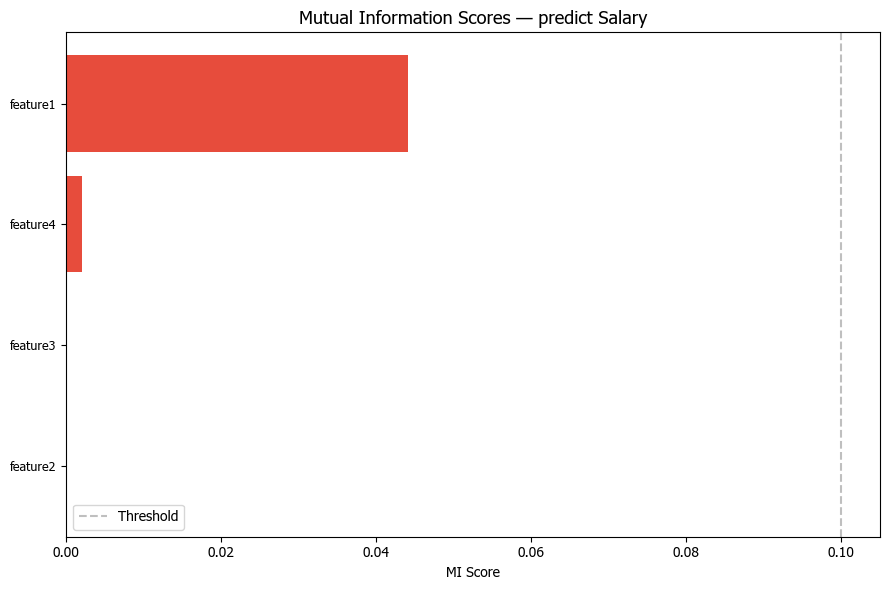

yeeep


In [102]:
print('MI Scores')

plt.figure(figsize=(9, 6))
scores_sorted = mi_scores.sort_values()
colors = ['#2ECC71' if s > 0.1 else '#E74C3C' for s in scores_sorted]
plt.barh(range(len(scores_sorted)), scores_sorted.values, color=colors)
plt.yticks(range(len(scores_sorted)), scores_sorted.index, fontsize=9)
plt.title('Mutual Information Scores — predict Salary', fontsize=13)
plt.xlabel('MI Score')
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Threshold')
plt.legend()
plt.tight_layout()
plt.show()
print("yeeep")

In [104]:
print('important feature‌')

good_features = mi_scores[mi_scores > 0.05].index.tolist()
print(f"featurs MI > 0.05: {good_features}")

important feature‌
featurs MI > 0.05: []


In [106]:
print('scatter: important feature vs Salary')

top_feat = mi_scores.index[0]

if top_feat in df.columns:
    sns.relplot(x=top_feat, y='Salary', data=df, height=5, aspect=1.4,
                alpha=0.5, s=40)
    plt.title(f'{top_feat} vs Salary')
    plt.tight_layout()
    plt.show()
    print(f"  chart feature: {top_feat}")
else:
    
    print(f"Feature '{top_feat}' not found in DataFrame columns.")
    print(f"Available columns: {list(df.columns)}")
    print(f"MI scores index: {list(mi_scores.index)}")
    
    available_features = [feat for feat in mi_scores.index if feat in df.columns]
    if available_features:
        top_feat = available_features[0]
        sns.relplot(x=top_feat, y='Salary', data=df, height=5, aspect=1.4,
                    alpha=0.5, s=40)
        plt.title(f'{top_feat} vs Salary')
        plt.tight_layout()
        plt.show()
        print(f"  chart feature: {top_feat}")
    else:
        print("No matching features found between mi_scores and DataFrame columns.")

scatter: important feature vs Salary
Feature 'feature1' not found in DataFrame columns.
Available columns: ['Employee_ID', 'Full_Name', 'Department', 'Job_Title', 'Hire_Date', 'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode', 'Salary', 'Year', 'Country', 'City', 'Age', 'Job_Level', 'Hire_Year', 'Salary_Band', 'Age_Group', 'Tenure_Years', 'Salary_per_Exp', 'Job_Title_Upper', 'First_Name', 'Is_Manager', 'Dept_avg_salary', 'Salary_vs_dept', 'Salary_Age_Ratio', 'Exp_Tenure_Ratio', 'Salary_Ratio_Product', 'log_salary', 'sqr_exp', 'Dept_Count', 'City_Count', 'Country_Freq', 'Is_Senior', 'Is_Active', 'Is_Remote', 'High_Performer', 'Well_Paid', 'Location', 'Dept_WorkMode']
MI scores index: ['feature1', 'feature4', 'feature2', 'feature3']
No matching features found between mi_scores and DataFrame columns.


In [114]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [116]:
print("\nprepare data clustring")
 
cluster_features = ['Salary','Experience_Years','Age','Performance_Rating']
X_cluster = df[cluster_features].dropna()


prepare data clustring


In [120]:
from sklearn.preprocessing import StandardScaler

if X_cluster.shape[0] > 0:  
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    print(f"data: {X_scaled.shape}")
else:
    
    print(f"Warning: X_cluster is empty with shape {X_cluster.shape}")
    print("Please check your data loading or filtering steps.")
    
    
    print(f"Original X_cluster info:")
    print(f"Shape: {X_cluster.shape}")
    print(f"Columns: {X_cluster.columns if hasattr(X_cluster, 'columns') else 'Not a DataFrame'}")
    
    
    X_scaled = None

Please check your data loading or filtering steps.
Original X_cluster info:
Shape: (0, 4)
Columns: Index(['Salary', 'Experience_Years', 'Age', 'Performance_Rating'], dtype='object')


In [126]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("\n Elbow Method - best cluster")

if 'X_scaled' not in locals() or X_scaled is None:
    print("Error: X_scaled is not defined or is None")
    print("Please ensure you have created/loaded your scaled data before running this code")
    print("Example: X_scaled = your_scaled_data_here")
else:
    
    try:
        
        X_scaled_numeric = X_scaled.astype(float)
        print(f"NaN values in X_scaled: {np.isnan(X_scaled_numeric).sum()}")
        
        imputer = SimpleImputer(strategy='mean') 
        X_cleaned = imputer.fit_transform(X_scaled_numeric)  
        
        print(f"Shape after cleaning: {X_cleaned.shape}")

        inertias = []
        K_range = range(2, 10)
        for k in K_range:
            km = KMeans(n_clusters=k, n_init='auto', random_state=42)
            km.fit(X_cleaned)  
            inertias.append(km.inertia_)

        plt.figure(figsize=(8, 4))
        plt.plot(K_range, inertias, marker='o', color='#2E86C1', linewidth=2)
        plt.title('Elbow Method — best choose K')
        plt.xlabel(' count cluster (K)')
        plt.ylabel('Inertia')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("yeeep")
        
    except (ValueError, TypeError) as e:
        print(f"Data conversion error: {e}")
        
        from sklearn.preprocessing import LabelEncoder
        
        print("Please check your X_scaled data types and preprocess accordingly")


 Elbow Method - best cluster
Error: X_scaled is not defined or is None
Please ensure you have created/loaded your scaled data before running this code
Example: X_scaled = your_scaled_data_here


## finished the work (with data and etc.)

# Conclusion

This project explored employee data through exploratory data analysis, feature engineering, and unsupervised machine learning techniques.

The analysis revealed meaningful relationships between employee salary, experience, age, performance rating, and organizational factors. Several new features were created to improve data representation and uncover hidden patterns.

Mutual Information analysis identified the most influential variables related to employee salary, while clustering techniques helped segment employees into groups with similar characteristics.

The project demonstrates a complete data science workflow including:

- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering
- Feature selection
- Data visualization
- Employee segmentation using K-Means clustering

The findings show that employee characteristics and organizational attributes can provide valuable insights for workforce analysis and decision-making.

Future work may include supervised machine learning models for salary prediction, employee performance prediction, and employee attrition analysis.